In [1]:
from tqdm import tqdm 

import torch 
import torch.nn.functional as F 
from torch.amp import autocast
from torch.amp import GradScaler

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


# Data

In [2]:
from torchvision.datasets import CIFAR10


base_train_dataset = CIFAR10(root="./data", train=True,download=False)
base_train_dataset.data.shape

(50000, 32, 32, 3)

In [3]:
x,y = base_train_dataset[0]

In [4]:
from torch.utils.data import Dataset
import torchvision.transforms as T


transform = T.Compose(
    [
        T.RandomResizedCrop(size=32, scale=(0.2,1.0)),
        T.RandomApply([T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)],p=0.8),
        T.RandomGrayscale(p=0.2),
        T.RandomSolarize(p=0.1,threshold=128),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ]
)

# in case you wondered where those numbers come from for mean and std to Normalize 
# print(torch.mean(torch.tensor(train_data.data / 255.),dim=(0,1,2)))
# print(torch.std(torch.tensor(train_data.data / 255.),dim=(0,1,2)))

class ImageDataset(Dataset): 
    def __init__(self, dataset, transform, num_crops=2):
        self.dataset = dataset
        self.transform = transform 
        self.num_crops = num_crops

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self,idx):
        image, label = self.dataset[idx]
        views = [self.transform(image) for _ in range(self.num_crops)]
        return views, label 


train_dataset = ImageDataset(
    dataset= base_train_dataset,
    transform = transform
)

(view1, view2), label = train_dataset[0]        
print(view1.shape)
print(view2.shape)
# I must remind the reader the label is not need it for upstream task 

torch.Size([3, 32, 32])
torch.Size([3, 32, 32])


In [5]:
from torch.utils.data import DataLoader 

train_loader = DataLoader(
    train_dataset, 
    batch_size=32,
    shuffle=True,
    drop_last=True
)

for (view1, view2),label in train_loader:
    print(view1.shape)
    break

torch.Size([32, 3, 32, 32])


# Model

In [6]:
from model import ResNet18, ImageSSL
from eval import LinearProbe, evaluate_linear_probe



proj_hidden_dim = 2048
proj_output_dim = 2048

backbone = ResNet18()
model = ImageSSL(
    backbone,
    features_dim= backbone.features_dim,
    proj_hidden_dim=proj_hidden_dim,
    proj_output_dim=proj_output_dim
)

linear_probe = LinearProbe(feature_dim=backbone.features_dim, num_classes=10)

model = model.to(device)
linear_probe = linear_probe.to(device)

# Learning Rate & Optimizer 

In [7]:
use_amp = False 
scaler = GradScaler(device.type, enabled=use_amp)

In [8]:
from lars import LARS 
from scheduler import WarmupCosineScheduler

lr = 0.3
weight_decay = 1.0e-4       # cfg.optim.weight_decay
warmup_epochs = 10          # cfg.optim.warmup_epochs
epochs = 300                # cfg.optim.epochs
base_lr = lr                # cfg.optim.lr
min_lr = 0.0                # cfg.optim.min_lr
warmup_start_lr = 3.0e-5    # cfg.optim.warmup_start_lr

optimizer = LARS(
    [
        {"params": model.parameters(),"lr":0.3}, # cfg.optim.lr
        {"params": linear_probe.parameters(),"lr":0.1}
    ],
    weight_decay=weight_decay,
    eta= 0.02,
    clip_lr=True,
    exclude_bias_n_norm=True,
    momentum=0.9
)

scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_epochs= warmup_epochs,
    max_epochs=epochs,
    base_lr=lr,
    min_lr=min_lr,
    warmup_start_lr=warmup_start_lr
)


In [ ]:
monitor_views, _ = next(iter(train_loader))
monitor_v1 = monitor_views[0].to(device)
monitor_v2 = monitor_views[1].to(device)

In [10]:
model.train()
linear_probe.train()

losses = []
linear_losses = []
z1_history, z2_history = [], []


for epoch in range(300): 
    linear_correct = 0
    linear_total = 0 


    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
    for batch_idx, (views,target) in enumerate(pbar):
        view1, view2 = views[0].to(device, non_blocking=True),views[1].to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        with autocast(device.type, enabled=use_amp): 
            features, z1 = model(view1)
            _       , z2 = model(view2)
            loss = F.mse_loss(z1,z2) 

        with torch.no_grad(): 
            features_frozen = features.detach().float()

        linear_outputs = linear_probe(features_frozen)
        linear_loss = F.cross_entropy(linear_outputs,target)

        _, predicted = linear_outputs.max(1)
        linear_correct_batch = predicted.eq(target).sum().item()

        total_loss_batch = loss + linear_loss 

        optimizer.zero_grad()
        scaler.scale(total_loss_batch).backward()
        scaler.step(optimizer)
        scaler.update()


        linear_total += target.size(0)
        linear_correct += linear_correct_batch

        pbar.set_postfix(
            {
                "Loss" : f"{loss.item():.4f}",
                "Linear": f"{linear_loss.item():.4f}",
                "Acc": f"{100. * linear_correct/linear_total:.2f}%"
            }
        )

    scheduler.step(epoch)
    losses.append(loss.item())
    linear_losses.append(linear_loss.item())

    model.eval()
    with torch.no_grad():
        _, z1_epoch = model(monitor_v1)
        _, z2_epoch = model(monitor_v2)
    z1_history.append(z1_epoch.detach().cpu())  # .detach() is defensive here. 
    z2_history.append(z2_epoch.detach().cpu())  # .detach() is defensive here. 
    model.train()




Epoch 28:  58%|█████▊    | 911/1562 [04:17<03:04,  3.53it/s, Loss=0.0000, Linear=2.2949, Acc=10.33%]   


KeyboardInterrupt: 

In [52]:
print(len(z1_history)) 
print(z1_history[0].shape)

28
torch.Size([32, 2048])


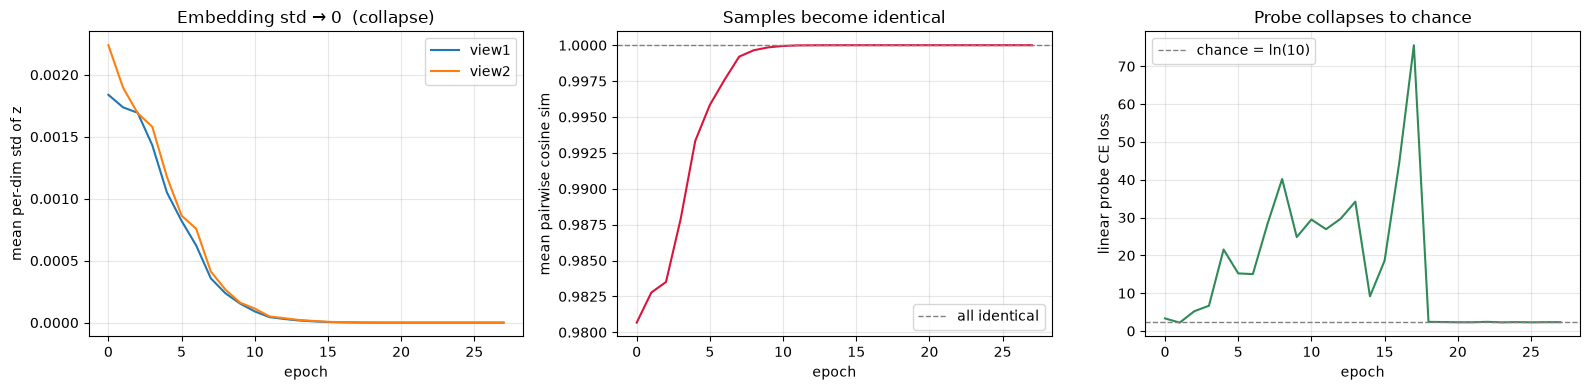

z std:   start=1.8388e-03  end=1.2993e-12
cos sim: start=0.9807   end=1.0000


In [12]:
import matplotlib.pyplot as plt

# z*_history: list (one entry per epoch) of tensors [batch, proj_dim]
epochs_ran = range(len(z1_history))

# --- Collapse signal 1: average per-dimension std across the monitor batch ---
# If every input maps to the same vector, std across the batch -> 0.
z1_std = [z.std(dim=0).mean().item() for z in z1_history]
z2_std = [z.std(dim=0).mean().item() for z in z2_history]

# --- Collapse signal 2: mean pairwise cosine similarity between samples ---
# All embeddings identical -> every off-diagonal pair has cosine sim ~1.
def mean_pairwise_cossim(z):
    zn = F.normalize(z, dim=1)
    sim = zn @ zn.T                      # [batch, batch]
    n = sim.size(0)
    off_diag = sim.sum() - sim.diag().sum()
    return (off_diag / (n * (n - 1))).item()

z1_cos = [mean_pairwise_cossim(z) for z in z1_history]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, z1_std, label="view1")
axes[0].plot(epochs_ran, z2_std, label="view2")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("mean per-dim std of z")
axes[0].set_title("Embedding std → 0  (collapse)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, z1_cos, color="crimson")
axes[1].axhline(1.0, ls="--", color="gray", lw=1, label="all identical")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean pairwise cosine sim")
axes[1].set_title("Samples become identical")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Context: linear probe cross-entropy vs the chance floor ln(10) ---
import math
axes[2].plot(range(len(linear_losses)), linear_losses, color="seagreen")
axes[2].axhline(math.log(10), ls="--", color="gray", lw=1, label="chance = ln(10)")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("linear probe CE loss")
axes[2].set_title("Probe collapses to chance")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"z std:   start={z1_std[0]:.4e}  end={z1_std[-1]:.4e}")
print(f"cos sim: start={z1_cos[0]:.4f}   end={z1_cos[-1]:.4f}")


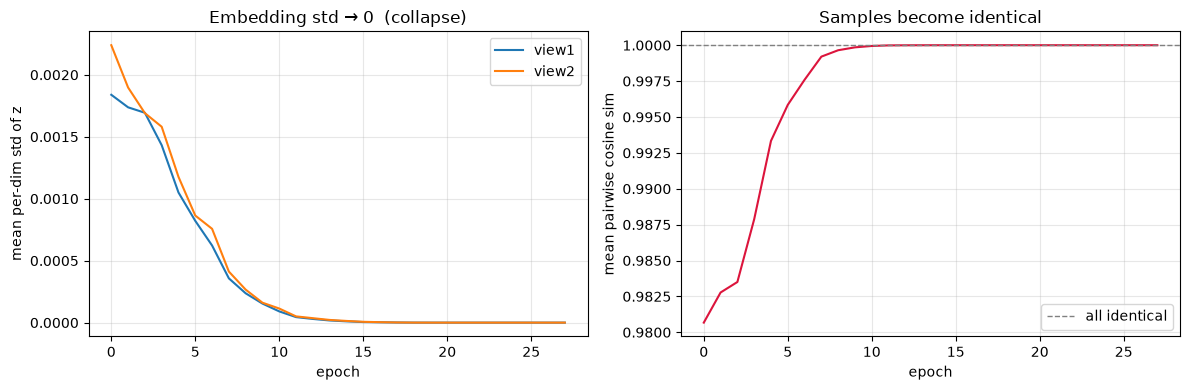

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, z1_std, label="view1")
axes[0].plot(epochs_ran, z2_std, label="view2")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("mean per-dim std of z")
axes[0].set_title("Embedding std → 0  (collapse)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, z1_cos, color="crimson")
axes[1].axhline(1.0, ls="--", color="gray", lw=1, label="all identical")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mean pairwise cosine sim")
axes[1].set_title("Samples become identical")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [37]:
for i,j in zip(z1_history, z2_history): 
    print(torch.allclose(i,j))  # checking z1 and z2 becoming equal 
    # print(i.std(dim=0))
    print(torch.all(i.std(dim=0) < 1e-4).item())    # std becomes 0, no features learned 
    print('---'*10)
    


False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
False
------------------------------
False
True
------------------------------
False
True
------------------------------
False
True
------------------------------
False
True
------------------------------
False
True
------------------------------
False
True
------------------------------
False
True
------------------------------
False
True
------------------------------
False
True
------------------------------
True
True
------------------------------
True
True
------------------------------
True
True
------------------------------
True
True
----------------

In [54]:
z1z2_cos = [F.cosine_similarity(a, b, dim=1).mean().item()
            for a, b in zip(z1_history, z2_history)]
z1z2_cos

[0.9796612858772278,
 0.9834887385368347,
 0.9856762886047363,
 0.9879800081253052,
 0.9933209419250488,
 0.9961496591567993,
 0.997214138507843,
 0.9991421699523926,
 0.999626636505127,
 0.9998531341552734,
 0.9999341368675232,
 0.9999861717224121,
 0.999992847442627,
 0.999997615814209,
 0.9999991059303284,
 0.9999998211860657,
 0.9999999403953552,
 1.0,
 0.9999999403953552,
 0.9999998211860657,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999998807907104,
 1.0,
 1.0,
 1.0]

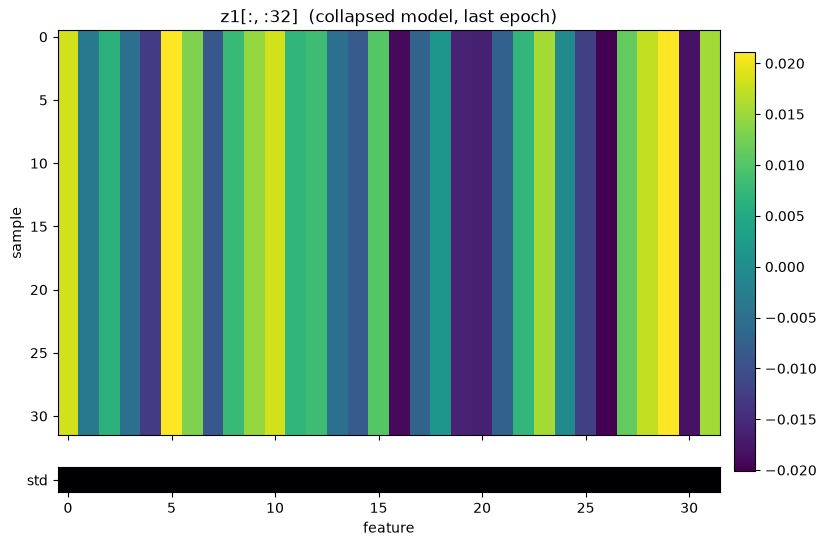

In [66]:
import numpy as np

# pick which epoch's monitor batch to inspect (-1 = last / most collapsed)
z = z1_history[-1][:, :32].numpy()   # (samples, first 32 features)
std = z.std(axis=0)                   # per-feature std across the batch

fig, (ax_map, ax_std) = plt.subplots(
    2, 1, figsize=(9, 6),
    gridspec_kw={"height_ratios": [16, 1], "hspace": 0.15},
    sharex=True,
)

# heatmap: rows = samples, cols = features
im = ax_map.imshow(z, aspect="auto", cmap="viridis")
ax_map.set_ylabel("sample")
ax_map.set_title("z1[:, :32]  (collapsed model, last epoch)")
fig.colorbar(im, ax=[ax_map, ax_std], fraction=0.03, pad=0.02)

# thin std bar aligned under each feature column
# pin vmin/vmax to a healthy reference (~1.0) so imshow doesn't auto-stretch
# the tiny residual std values across the full colormap. collapsed -> stays dark.
ax_std.imshow(std[None, :], aspect="auto", cmap="magma", vmin=0.0, vmax=1.0)
ax_std.set_yticks([0])
ax_std.set_yticklabels(["std"])
ax_std.set_xlabel("feature")

plt.show()


### will the encoder produce the same state (given there is a projector) ?


In [99]:
(v1, v2), label = train_dataset[0]   
print(v1.shape)

model.eval()
with torch.no_grad():
    v1 = v1.to(device)
    v2 = v2.to(device)
    f1, _ = model(v1.unsqueeze(0))
    f2, _ = model(v2.unsqueeze(0))

print(f1.shape)
print(f2.shape)
    



torch.Size([3, 32, 32])
torch.Size([1, 512])
torch.Size([1, 512])


In [63]:
z1_history[-1].std(dim=0).max().item()

7.823359737813007e-10

In [67]:
from pathlib import Path 

ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / "Image_ssl_draft0.pt"

In [68]:


torch.save(
    {
        "model": model.state_dict(),
        "linear_probe": linear_probe.state_dict(),
        "optimizer":optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if hasattr(scheduler, "state_dict") else None,
        "epoch":epoch
    },
    ckpt_path
)

In [69]:
torch.save(
    {"z1_history": z1_history, "z2_history": z2_history},
    ckpt_dir / "z_history.pt",
)


In [74]:
z1_history[-1]

tensor([[ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        ...,
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015]])

In [75]:
z2_history[-1]

tensor([[ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        ...,
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015],
        [ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015]])

# The Model produce converges to `constant function`

- more appropiate would be in the input are real images (batch of real images), 
from validation dataset 

In [ ]:
model.eval()
with torch.no_grad(): 
    _, zz1 = model(torch.randn(1,3,32,32,device=device))
    # _, zz2 = model(torch.randint(-5,5,(1,3,32,32), dtype=torch.float, device=device))
    _, zz2 = model(torch.randn(1,3,32,32,device=device) * 2)


In [85]:
zz1 

tensor([[ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015]],
       device='mps:0')

In [86]:
zz2

tensor([[ 0.0183, -0.0034,  0.0063,  ...,  0.0177,  0.0201,  0.0015]],
       device='mps:0')